# single-load

In [8]:
%load_ext autoreload
%autoreload 2

%pip install -r requirements.txt
%pip install -e .
%pip install matplotlib

import selfmade.nb101 as nb101

records = r'.\datas\nasbench_full.tfrecord'
space = nb101.NASBench101Space()
evaluator = nb101.NASBench101Evaluator(records, space)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python37\python.exe -m pip install --upgrade pip' command.



Obtaining file:///E:/coding/uit_bs/nuro_evo/nb-new
  Attempting uninstall: nasbench
    Found existing installation: nasbench 1.0
    Uninstalling nasbench-1.0:
      Successfully uninstalled nasbench-1.0
  Running setup.py develop for nasbench
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python37\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python37\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.
Loading dataset from file... This may take a few minutes...
Loaded dataset in 642 seconds


In [9]:
from sklearn.ensemble import RandomForestRegressor
import secrets
import matplotlib.pyplot as plt
import pandas as pd

# main functions

In [10]:
pop_size = 100
total_gen = 20
# Set seed để tạo tính công bằng cho 2 lượt chạy khác nhau
nb101.set_seed(42)

In [11]:
# Full vanilla (100 evals -> 10 pop, 10 iters)
def vanilla_run(size, loops):
    full_van = nb101.Population(size, space, evaluator)
    full_van.initialize()
    full_van.evolve_loop(total_gen=loops)
    return full_van

In [12]:
# Half vanilla, half guided (100 evals -> 10 pop, 5 val, 5 gui)
def guided_run(size, loops):
    split = int(loops/2)
    semi_van = nb101.Population(size, space, evaluator)
    semi_van.initialize()
    semi_van.evolve_loop(total_gen=split)

    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)
    fi = nb101.FeatureImportance(space)
    imp = fi.pipeline(semi_van.data, rf)
    imp

    gui = nb101.Guidance(space, imp, semi_van.config)
    gui.sortNsplit()
    gui.calculate_guidance()

    semi_van.evolve_loop(total_gen=split, guidance = gui)
    return semi_van


In [ ]:
fv = guided_run(pop_size, total_gen)
sv = vanilla_run(pop_size, total_gen)

# plot on full vanilla

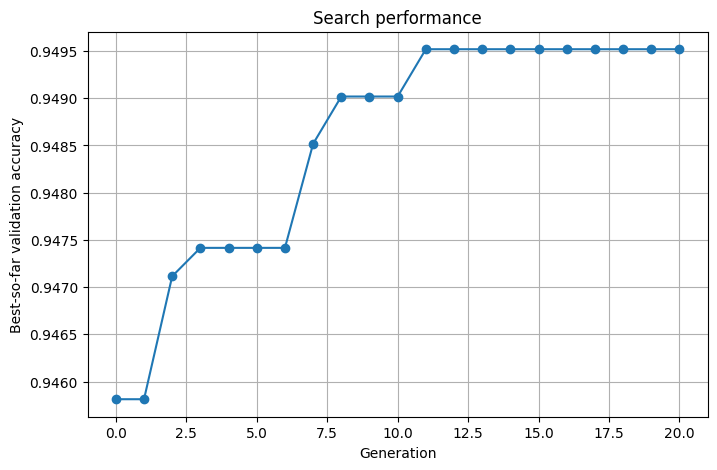

In [14]:
hist = pd.DataFrame(fv.best_history)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["best_so_far"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Search performance")
plt.grid(True)
plt.show()

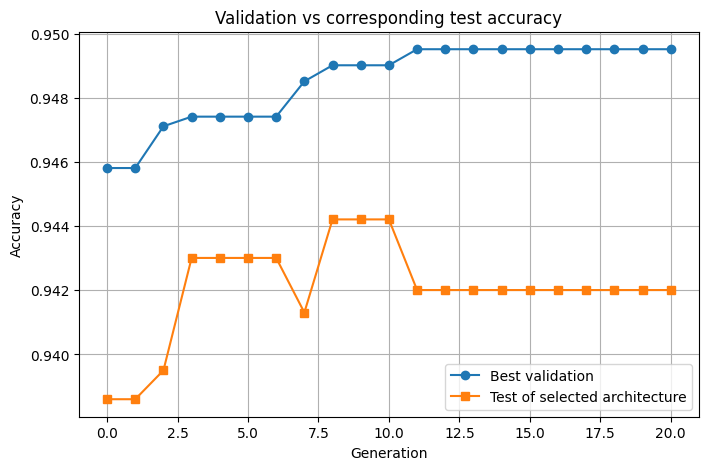

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist["generation"],
    hist["best_val"],
    marker="o",
    label="Best validation"
)

plt.plot(
    hist["generation"],
    hist["best_test"],
    marker="s",
    label="Test of selected architecture"
)

plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Validation vs corresponding test accuracy")
plt.legend()
plt.grid(True)
plt.show()

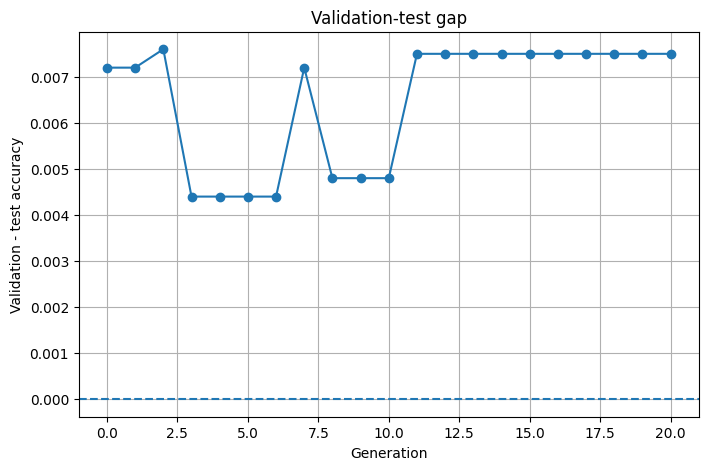

In [16]:
hist["val_test_gap"] = (
    hist["best_val"] - hist["best_test"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["val_test_gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Generation")
plt.ylabel("Validation - test accuracy")
plt.title("Validation-test gap")
plt.grid(True)
plt.show()

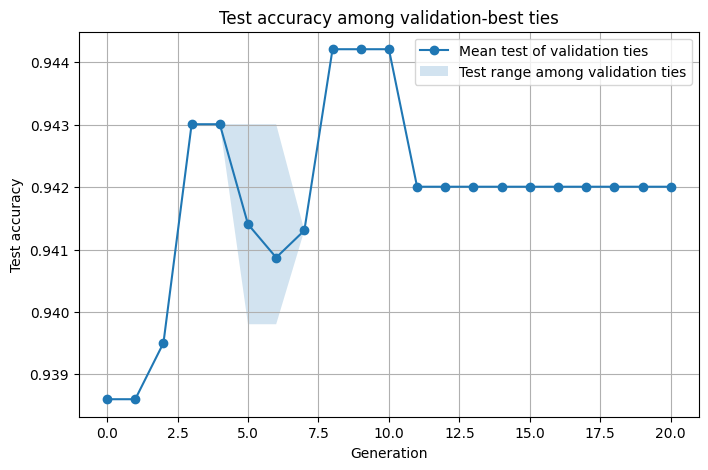

In [17]:
plt.figure(figsize=(8, 5))

x = hist["generation"]

plt.plot(
    x,
    hist["tied_test_mean"],
    marker="o",
    label="Mean test of validation ties"
)

plt.fill_between(
    x,
    hist["tied_test_min"],
    hist["tied_test_max"],
    alpha=0.2,
    label="Test range among validation ties"
)

plt.xlabel("Generation")
plt.ylabel("Test accuracy")
plt.title("Test accuracy among validation-best ties")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
df = pd.DataFrame(fv.data)

population_stats = (
    df.groupby("generation")["validation_accuracy"]
      .agg(["mean", "median", "min", "max"])
      .reset_index()
)

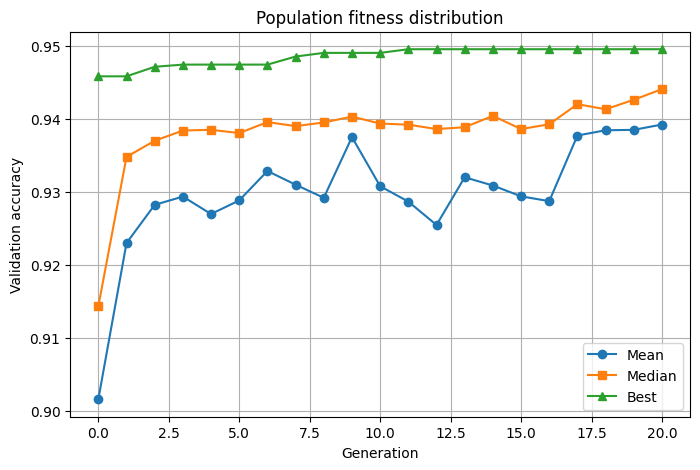

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    population_stats["generation"],
    population_stats["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    population_stats["generation"],
    population_stats["median"],
    marker="s",
    label="Median"
)

plt.plot(
    population_stats["generation"],
    population_stats["max"],
    marker="^",
    label="Best"
)

plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Population fitness distribution")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def genome_signature(rep):
    return (
        rep["code"],
        tuple(rep["operations"])
    )

In [21]:
df["signature"] = df["representation"].apply(genome_signature)

diversity = (
    df.groupby("generation")["signature"]
      .nunique()
      .reset_index(name="unique_architectures")
)

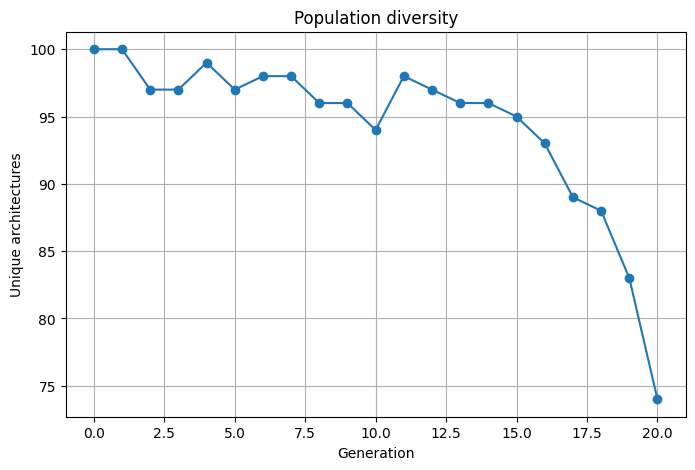

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    diversity["generation"],
    diversity["unique_architectures"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Unique architectures")
plt.title("Population diversity")
plt.grid(True)
plt.show()

plot on vanilla + guided

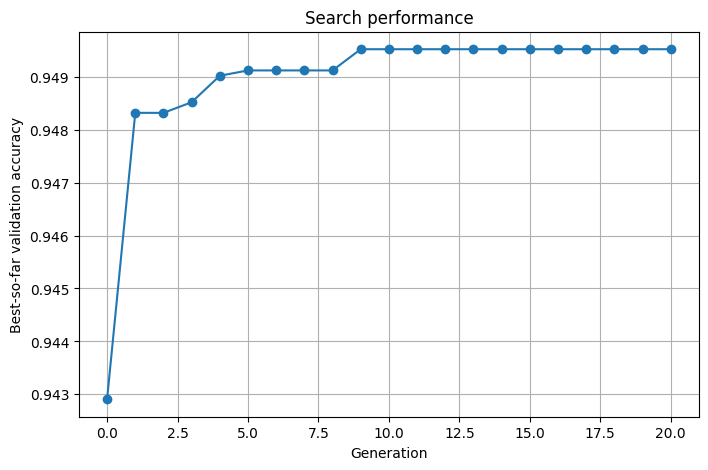

In [23]:
hist = pd.DataFrame(sv.best_history)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["best_so_far"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Search performance")
plt.grid(True)
plt.show()

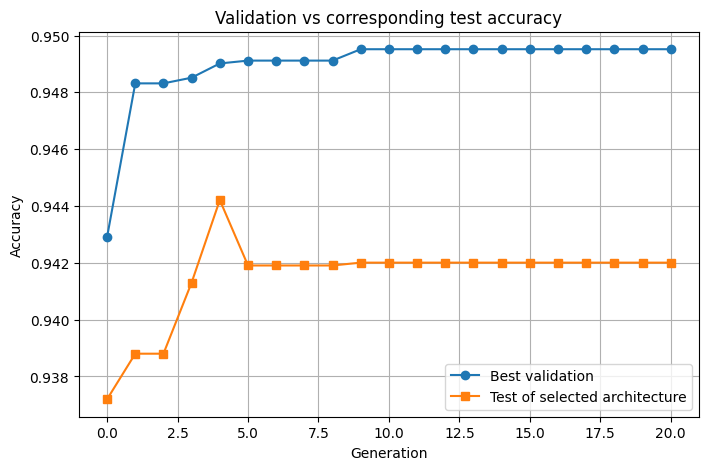

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist["generation"],
    hist["best_val"],
    marker="o",
    label="Best validation"
)

plt.plot(
    hist["generation"],
    hist["best_test"],
    marker="s",
    label="Test of selected architecture"
)

plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Validation vs corresponding test accuracy")
plt.legend()
plt.grid(True)
plt.show()

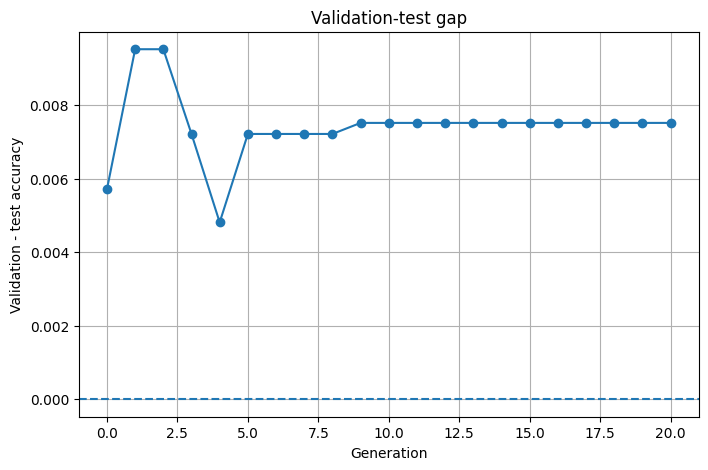

In [25]:
hist["val_test_gap"] = (
    hist["best_val"] - hist["best_test"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["val_test_gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Generation")
plt.ylabel("Validation - test accuracy")
plt.title("Validation-test gap")
plt.grid(True)
plt.show()

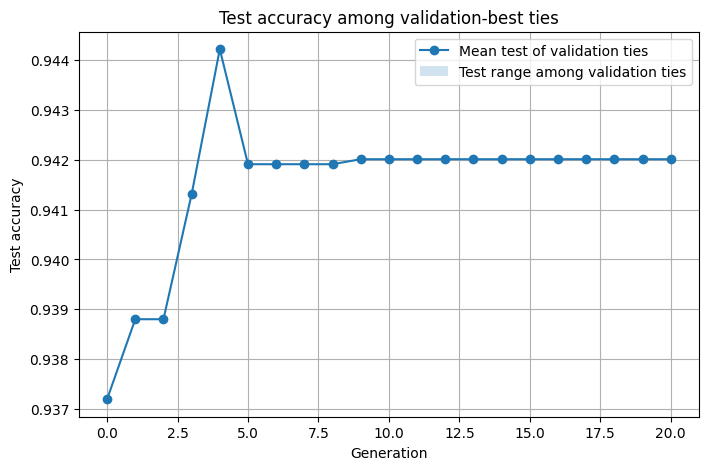

In [26]:
plt.figure(figsize=(8, 5))

x = hist["generation"]

plt.plot(
    x,
    hist["tied_test_mean"],
    marker="o",
    label="Mean test of validation ties"
)

plt.fill_between(
    x,
    hist["tied_test_min"],
    hist["tied_test_max"],
    alpha=0.2,
    label="Test range among validation ties"
)

plt.xlabel("Generation")
plt.ylabel("Test accuracy")
plt.title("Test accuracy among validation-best ties")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
df = pd.DataFrame(sv.data)

population_stats = (
    df.groupby("generation")["validation_accuracy"]
      .agg(["mean", "median", "min", "max"])
      .reset_index()
)

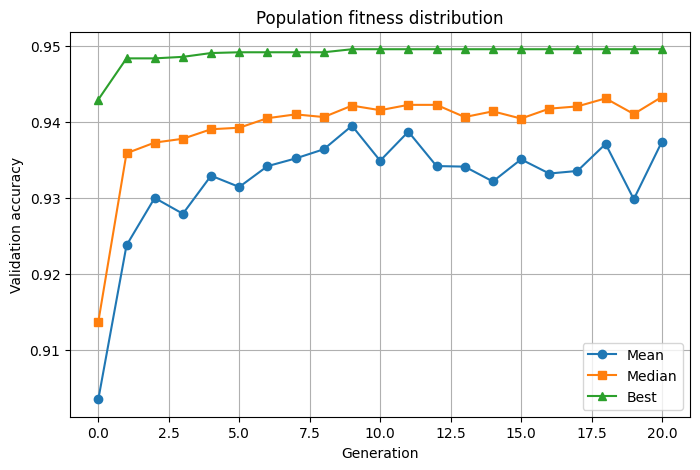

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    population_stats["generation"],
    population_stats["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    population_stats["generation"],
    population_stats["median"],
    marker="s",
    label="Median"
)

plt.plot(
    population_stats["generation"],
    population_stats["max"],
    marker="^",
    label="Best"
)

plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Population fitness distribution")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
df["signature"] = df["representation"].apply(genome_signature)

diversity = (
    df.groupby("generation")["signature"]
      .nunique()
      .reset_index(name="unique_architectures")
)

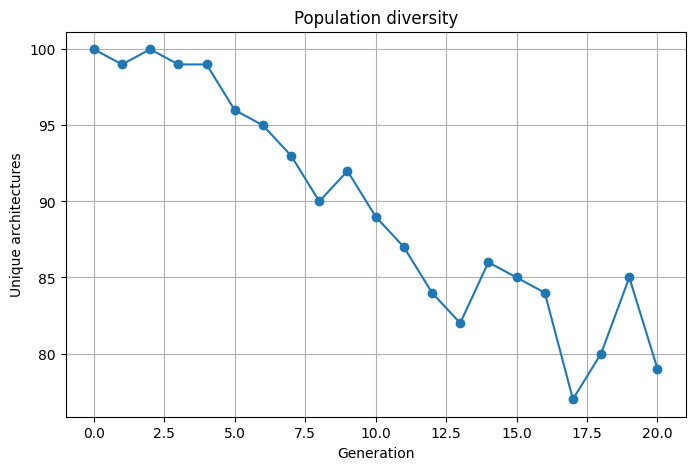

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    diversity["generation"],
    diversity["unique_architectures"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Unique architectures")
plt.title("Population diversity")
plt.grid(True)
plt.show()

# 10 seed loop

In [31]:
def loopy_loop(n_runs, size, loops):
    fv_seed = []
    sv_seed = []
    seeds = []

    for run in range(n_runs):
        s = secrets.randbits(32)
        seeds.append(s)

        print(f"Running {run + 1}/{n_runs} | seed = {s}")

        nb101.set_seed(s)

        fv = vanilla_run(size, loops)
        fv_seed.append(fv)

        sv = guided_run(size, loops)
        sv_seed.append(sv)

    return fv_seed, sv_seed, seeds

In [32]:
fv, sv, seeds = loopy_loop(20, pop_size, 20)
# fv, sv, seeds = loopy_loop(20, pop_size * 2, 50)

Running 1/20 | seed = 4023496157
Best performance: 0.9421073794364929
recording generation 0
finished recording
Generation 1 - Best performance: 0.9436097741127014
recording generation 1
finished recording
Generation 2 - Best performance: 0.9472155570983887
recording generation 2
finished recording
Generation 3 - Best performance: 0.9472155570983887
recording generation 3
finished recording
Generation 4 - Best performance: 0.9472155570983887
recording generation 4
finished recording
Generation 5 - Best performance: 0.9472155570983887
recording generation 5
finished recording
Generation 6 - Best performance: 0.9472155570983887
recording generation 6
finished recording
Generation 7 - Best performance: 0.9472155570983887
recording generation 7
finished recording
Generation 8 - Best performance: 0.9472155570983887
recording generation 8
finished recording
Generation 9 - Best performance: 0.9472155570983887
recording generation 9
finished recording
Generation 10 - Best performance: 0.947215

In [33]:
def make_history_df(runs, seeds, method):
    rows = []

    for pop, seed in zip(runs, seeds):
        for h in pop.best_history:
            rows.append({
                "seed": seed,
                "method": method,
                "generation": h["generation"],
                "best_val": h["best_val"],
                "best_so_far": h["best_so_far"],
                "best_test": h["best_test"],
                "tied_test_min": h["tied_test_min"],
                "tied_test_max": h["tied_test_max"],
                "tied_test_mean": h["tied_test_mean"],
                "num_tied": h["num_tied"],
            })

    return pd.DataFrame(rows)

In [34]:
vanilla_df = make_history_df(fv,seeds,"Vanilla")
guided_df = make_history_df(sv,seeds,"Guided")

history_df = pd.concat([vanilla_df, guided_df],ignore_index=True)

In [35]:
import numpy as np

def summarize(df):
    summary = (
        df.groupby(["method", "generation"])["best_so_far"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    summary["sem"] = (
        summary["std"] /
        np.sqrt(summary["count"])
    )

    summary["ci95"] = 1.96 * summary["sem"]

    return summary

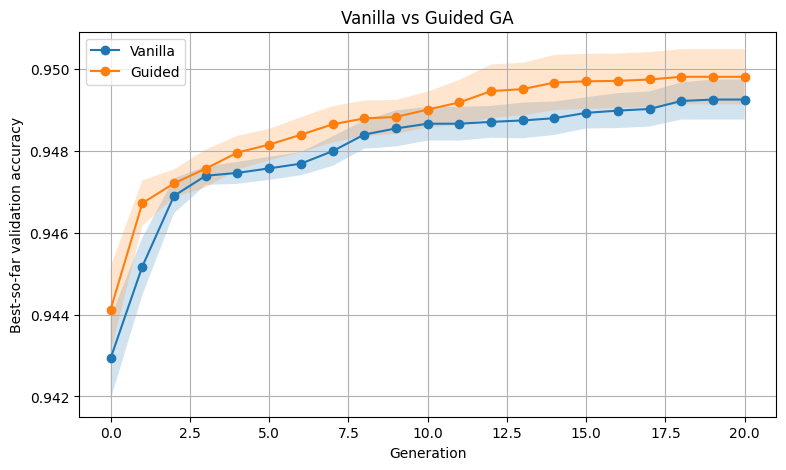

In [36]:
summary = summarize(history_df)

plt.figure(figsize=(9, 5))

for method in ["Vanilla", "Guided"]:
    d = summary[summary["method"] == method]

    plt.plot(
        d["generation"],
        d["mean"],
        marker="o",
        label=method
    )

    plt.fill_between(
        d["generation"],
        d["mean"] - d["ci95"],
        d["mean"] + d["ci95"],
        alpha=0.2
    )

plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Vanilla vs Guided GA")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
def final_results(df):
    final = (
        df.sort_values("generation")
        .groupby(["seed", "method"])
        .tail(1)
    )

    return final

In [38]:
final = final_results(history_df)

pivot = final.pivot(
    index="seed",
    columns="method",
    values="best_so_far"
)

pivot["improvement"] = (
    pivot["Guided"] - pivot["Vanilla"]
)

print(pivot)

method        Guided   Vanilla  improvement
seed                                       
157046994   0.948317  0.948317     0.000000
185477332   0.949519  0.948117     0.001402
217422460   0.948518  0.949018    -0.000501
307434407   0.947216  0.948518    -0.001302
347968446   0.951823  0.949519     0.002304
924379647   0.949519  0.949519     0.000000
1496834156  0.951122  0.949018     0.002103
1736545192  0.951823  0.949018     0.002805
1955551040  0.949519  0.951122    -0.001603
2436525650  0.949018  0.949519    -0.000501
3022280344  0.947216  0.951823    -0.004607
3068349804  0.949018  0.951823    -0.002805
3125571803  0.949519  0.948117     0.001402
3206949509  0.950721  0.949519     0.001202
3224750948  0.950321  0.949018     0.001302
3240873984  0.949519  0.948918     0.000601
3789556107  0.951823  0.948618     0.003205
4023496157  0.951823  0.949018     0.002805
4093677047  0.951823  0.948518     0.003305
4192371281  0.948117  0.948117     0.000000


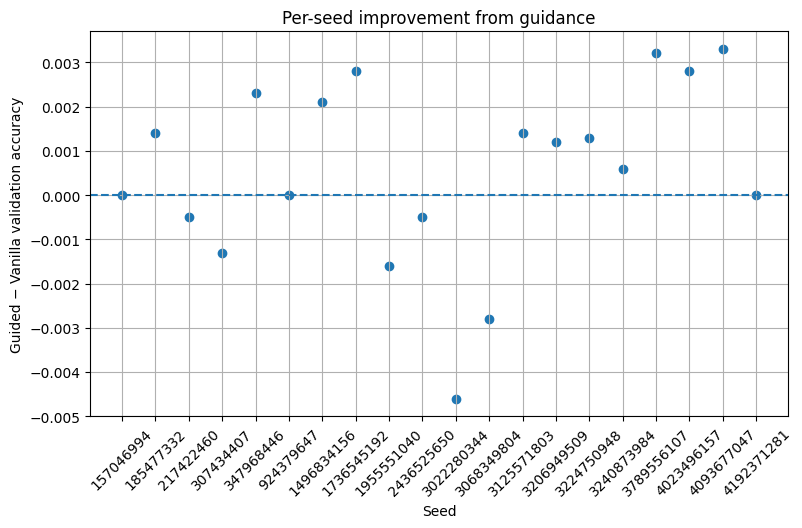

In [39]:
plt.figure(figsize=(9, 5))

x = np.arange(len(pivot))

plt.axhline(
    0,
    linestyle="--"
)

plt.scatter(
    x,
    pivot["improvement"]
)

plt.xticks(
    x,
    [str(s) for s in pivot.index],
    rotation=45
)

plt.xlabel("Seed")
plt.ylabel("Guided − Vanilla validation accuracy")
plt.title("Per-seed improvement from guidance")
plt.grid(True)
plt.show()

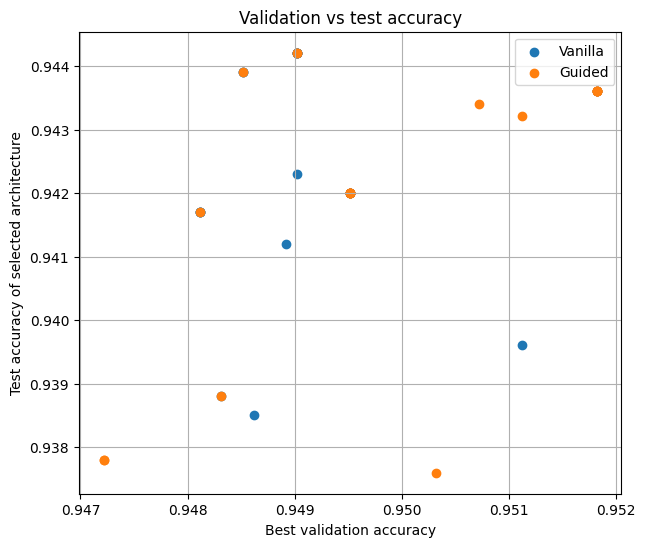

In [40]:
final_val = final.copy()

plt.figure(figsize=(7, 6))

for method in ["Vanilla", "Guided"]:
    d = final_val[final_val["method"] == method]

    plt.scatter(
        d["best_so_far"],
        d["best_test"],
        label=method
    )

plt.xlabel("Best validation accuracy")
plt.ylabel("Test accuracy of selected architecture")
plt.title("Validation vs test accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
final_val["val_test_gap"] = (
    final_val["best_so_far"]
    - final_val["best_test"]
)

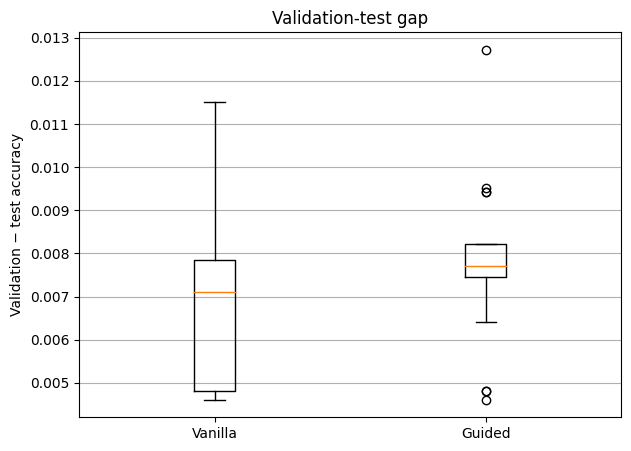

In [42]:
plt.figure(figsize=(7, 5))

groups = [
    final_val[
        final_val["method"] == "Vanilla"
    ]["val_test_gap"],

    final_val[
        final_val["method"] == "Guided"
    ]["val_test_gap"]
]

plt.boxplot(
    groups,
    labels=["Vanilla", "Guided"]
)

plt.ylabel("Validation − test accuracy")
plt.title("Validation-test gap")
plt.grid(True, axis="y")
plt.show()